In [1]:
library(tidyverse)

── Attaching core tidyverse packages ─────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ───────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
mva <- read_csv("./deseq2_mockAuxResc_results_36/K27_raw_counts.csv_aux_v_mock_results.csv")
rva <- read_csv("./deseq2_mockAuxResc_results_36/K27_raw_counts.csv_resc_v_aux_results.csv")
PAT <- 0.005
FCT <- 1.5

Rows: 11828 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): V1, directionality
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, padj
lgl (1): Significative

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 11828 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): V1, directionality
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, padj
lgl (1): Significative

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
sigboth <- mva$Significative == TRUE & rva$Significative == TRUE
table(sigboth)

sigboth
FALSE  TRUE 
11391   437 

In [4]:
dplot <- function(ft)
{
    f1 <- ft |> mutate(db = case_when(Significative == TRUE & directionality == "UP" ~ 'Up',
                                      Significative == TRUE & directionality == "DOWN" ~ "Down",
                                      .default = 'Unchanged'))
    f1$db <- as.factor(f1$db)
    f1$all <- "all"
    
    print(paste("Differentially Binding over Peaks |log2(FoldChange)| > 1.5 and q-Value < 0.001"))
    print(table(f1$db))
    print("---------------------------------------------------------------------")
    print(paste("DISTRIBUCION DE ADJUSTED P"))
    print(quantile(f1$padj, na.rm = T))
    print("---------------------------------------------------------------------")
    print(paste("DISTRIBUCION DE Log2FC ABSOLUTO"))
    print(quantile(abs(f1$log2FoldChange), na.rm = T))
    print("---------------------------------------------------------------------")
    print(ggplot (f1, aes(x= abs(log2FoldChange) ,y = all )) + geom_violin())
  
    print(ggplot (f1, aes(x= log2FoldChange ,y = all )) + geom_violin())
   
    print(ggplot (f1, aes(x= padj ,y = all )) + geom_violin())
   
    print(ggplot (f1, aes(x= log2FoldChange , color = db)) + geom_density())
   
    print(ggplot (f1, aes (y= -log2(padj), x = log2FoldChange, color = db)) + geom_point())
  

    f1$all <- NULL
    return(f1)
}

dthrexploration <- function (fg, patlad = c(0.001, 0.005, 0.01, 0.05), fctlad = c(2,1.5,1,0.5))
{
    dbrByFilter <- c()

    for (fp in fctlad){
        for (pp in patlad){
            ft <- fg |> mutate(db = case_when(abs(log2FoldChange) > fp & padj < pp ~ 'DBR' ,.default = 'Unchanged')) |> filter(db == 'DBR')
            todf <- c(fp,pp,nrow(ft),nrow(filter(ft,log2FoldChange > 0))/nrow(ft))
            dbrByFilter <- rbind(dbrByFilter, todf)
        }
    }
    colnames(dbrByFilter) <- c("log2FoldChange","padj","dbr_total","dbr_positive_fraction")
    return(dbrByFilter)
}

,log2FoldChange,padj,dbr_total,dbr_positive_fraction
todf,2.0,0.001,3242,1.0000000
todf,2.0,0.005,3927,0.9992361
todf,2.0,0.010,4227,0.9990537
todf,2.0,0.050,4800,0.9893750
todf,1.5,0.001,3242,1.0000000
todf,1.5,0.005,3927,0.9992361
todf,1.5,0.010,4227,0.9990537
todf,1.5,0.050,5096,0.9856750
todf,1.0,0.001,3242,1.0000000
todf,1.0,0.005,3927,0.9992361


[1] "Differentially Binding over Peaks |log2(FoldChange)| > 1.5 and q-Value < 0.001"

     Down Unchanged        Up 
        3      7901      3924 
[1] "---------------------------------------------------------------------"
[1] "DISTRIBUCION DE ADJUSTED P"
          0%          25%          50%          75%         100% 
1.275046e-09 4.503306e-04 1.254947e-01 5.200435e-01 9.993793e-01 
[1] "---------------------------------------------------------------------"
[1] "DISTRIBUCION DE Log2FC ABSOLUTO"
          0%          25%          50%          75%         100% 
0.0006941406 0.7583403639 1.5837651831 2.9245276533 6.9530295610 
[1] "---------------------------------------------------------------------"


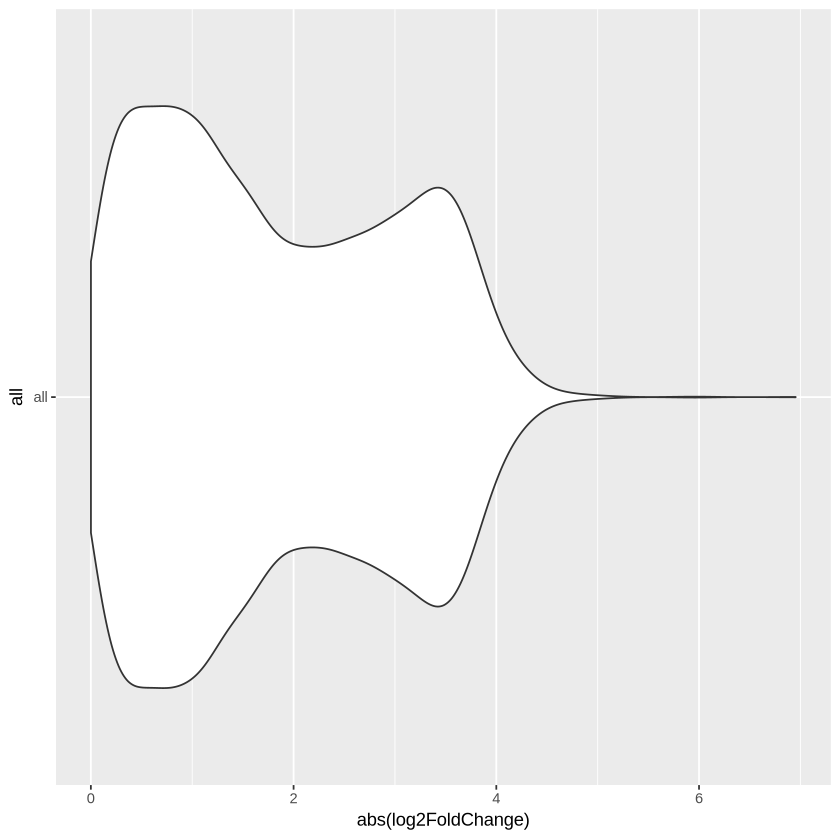

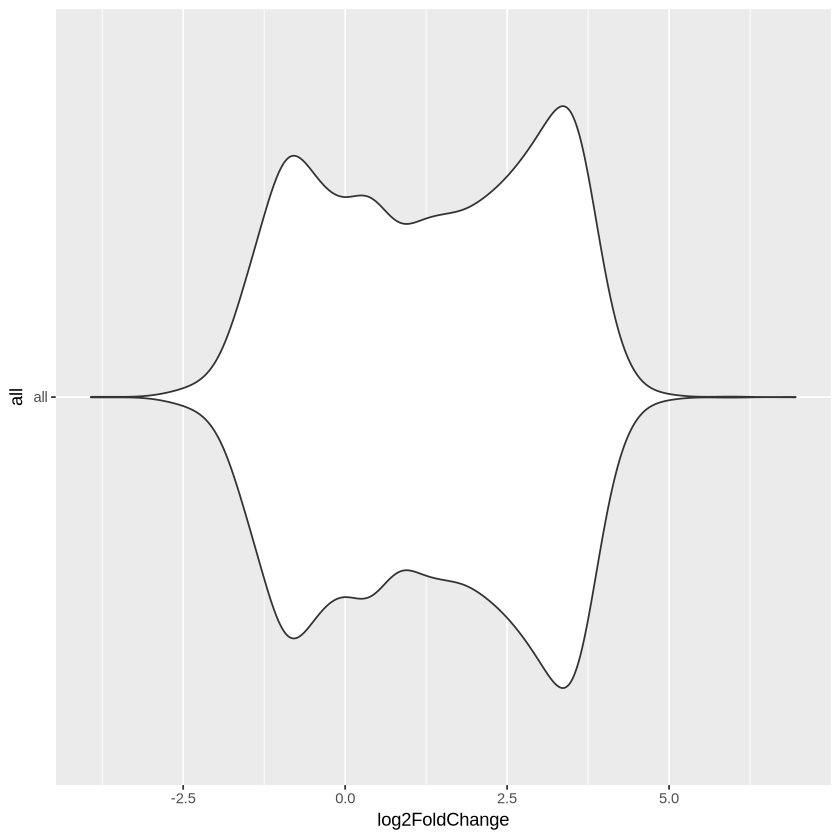

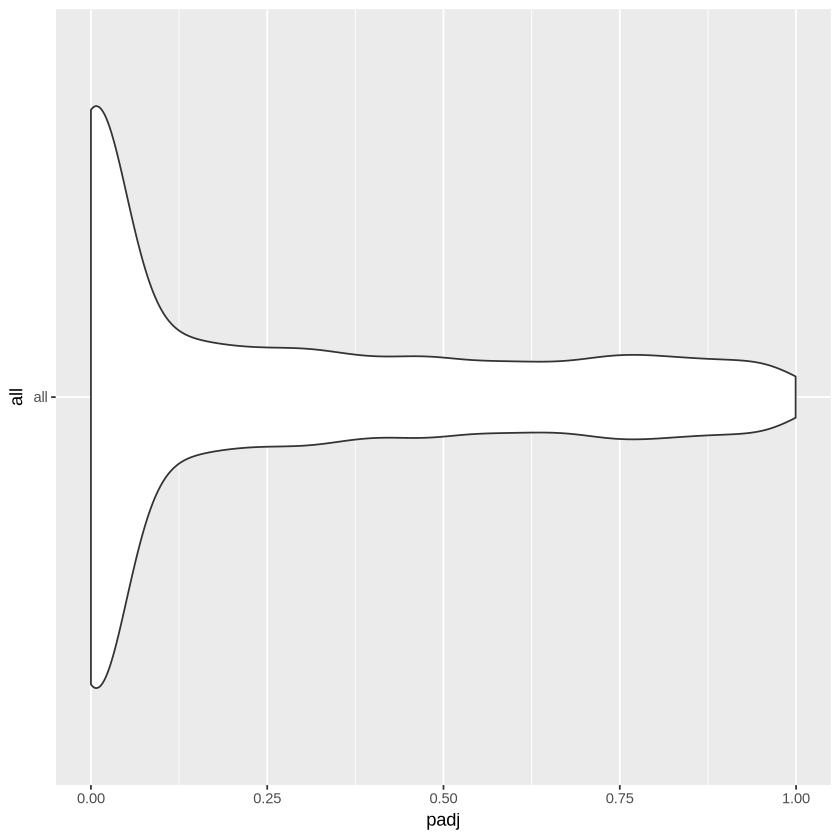

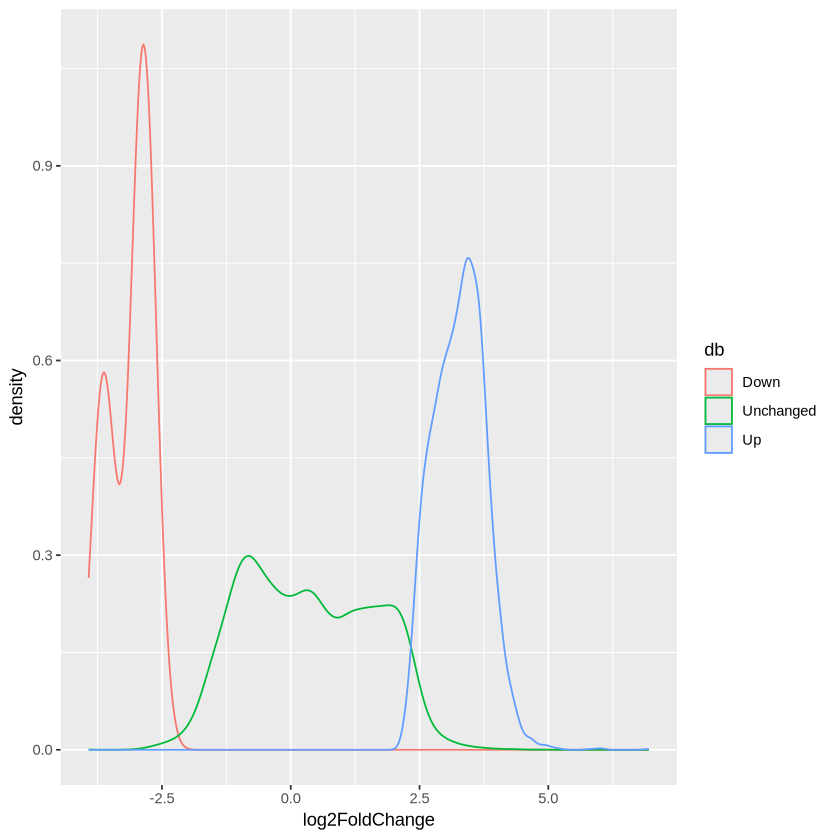

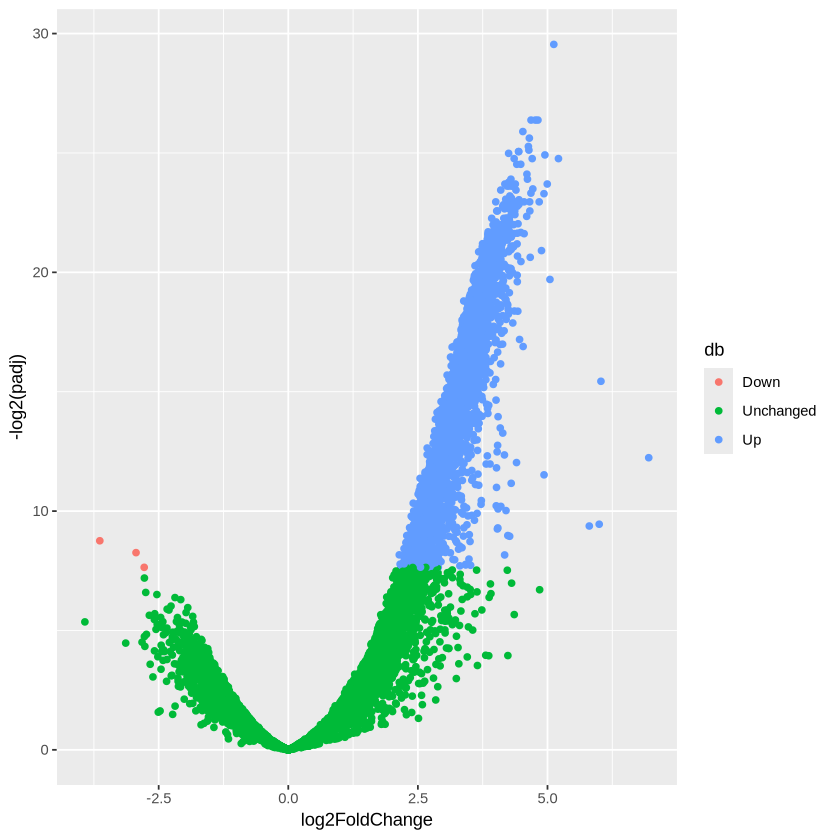

In [5]:
dthrexploration(rva)
rva <- dplot(rva)

,log2FoldChange,padj,dbr_total,dbr_positive_fraction
todf,2.0,0.001,17,0.00000000
todf,2.0,0.005,743,0.02826380
todf,2.0,0.010,1777,0.02982555
todf,2.0,0.050,4252,0.03668862
todf,1.5,0.001,17,0.00000000
todf,1.5,0.005,743,0.02826380
todf,1.5,0.010,1777,0.02982555
todf,1.5,0.050,5431,0.03682563
todf,1.0,0.001,17,0.00000000
todf,1.0,0.005,743,0.02826380


[1] "Differentially Binding over Peaks |log2(FoldChange)| > 1.5 and q-Value < 0.001"

     Down Unchanged        Up 
      722     11085        21 
[1] "---------------------------------------------------------------------"
[1] "DISTRIBUCION DE ADJUSTED P"
          0%          25%          50%          75%         100% 
0.0006693186 0.0180369024 0.0608248180 0.2391038904 0.9989455835 
[1] "---------------------------------------------------------------------"
[1] "DISTRIBUCION DE Log2FC ABSOLUTO"
         0%         25%         50%         75%        100% 
0.001156219 1.122952115 1.782350625 2.303293687 8.381646875 
[1] "---------------------------------------------------------------------"


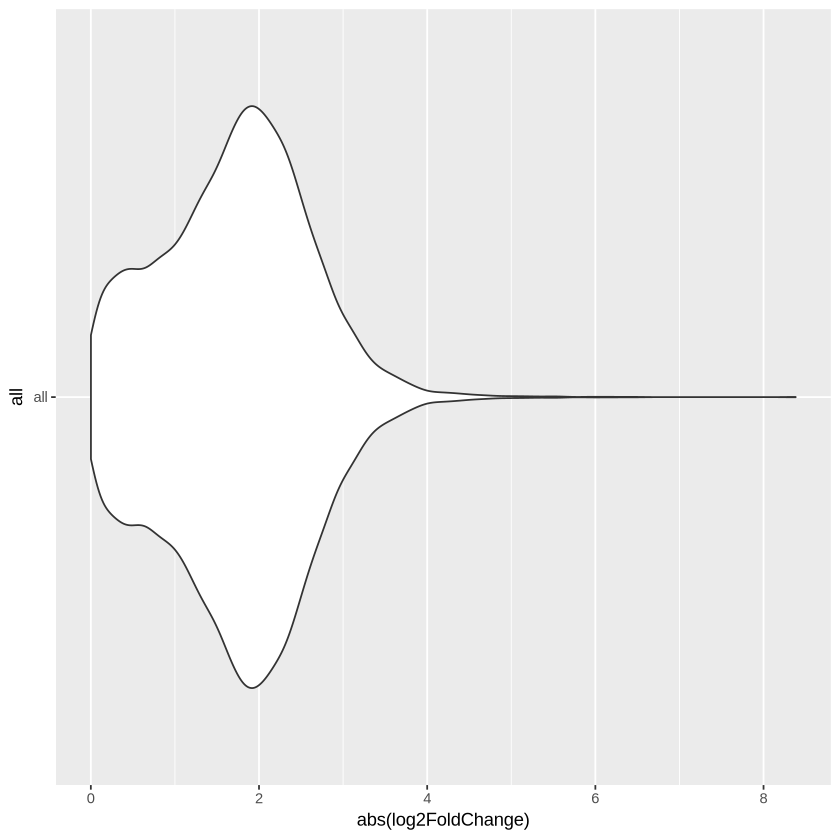

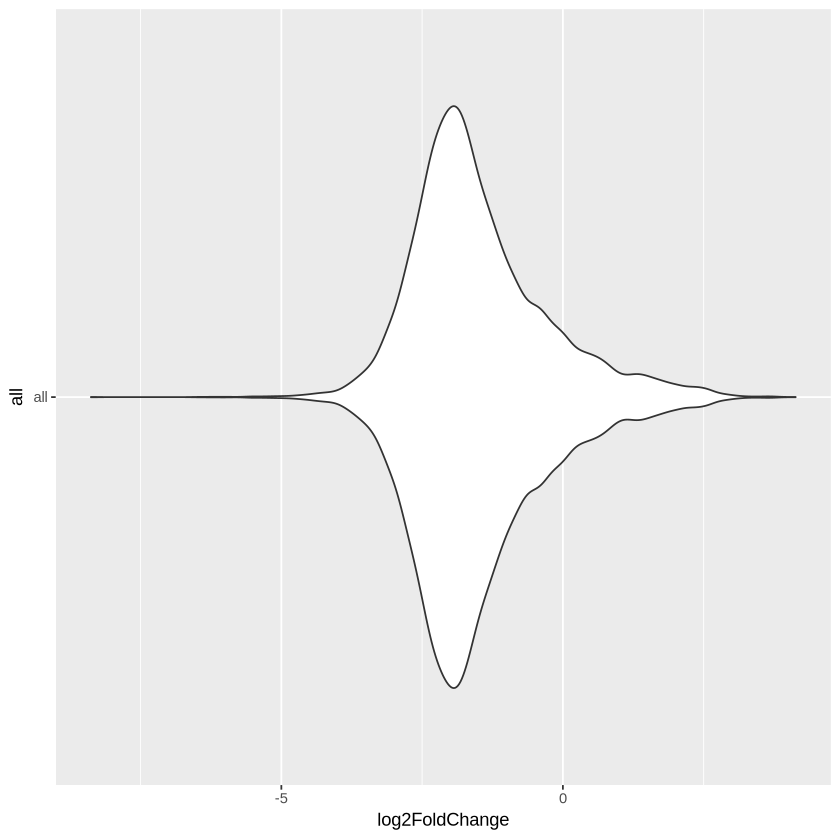

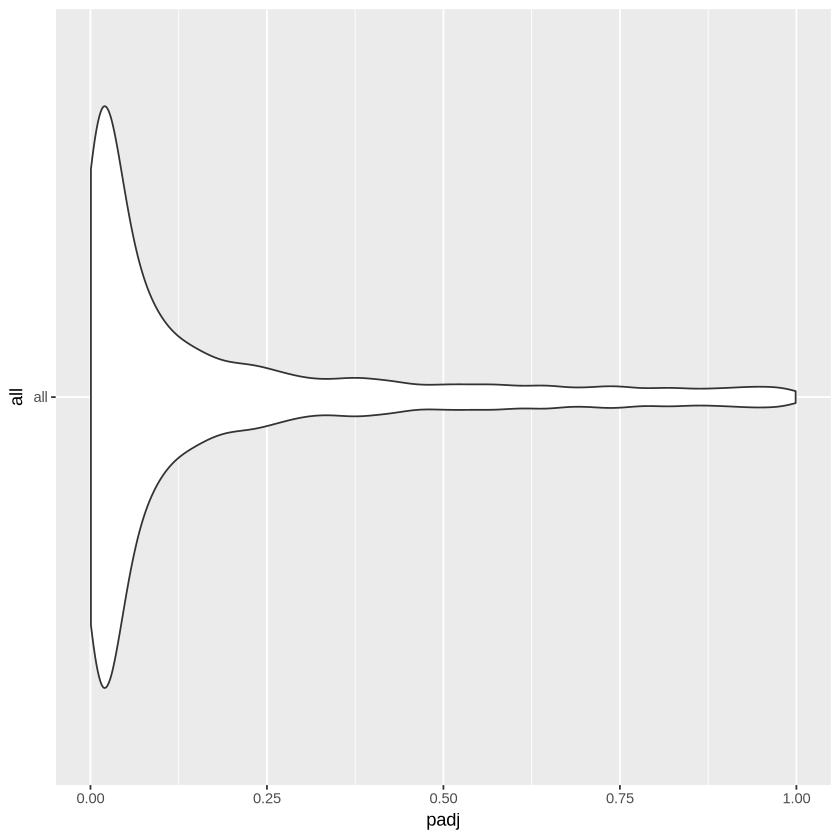

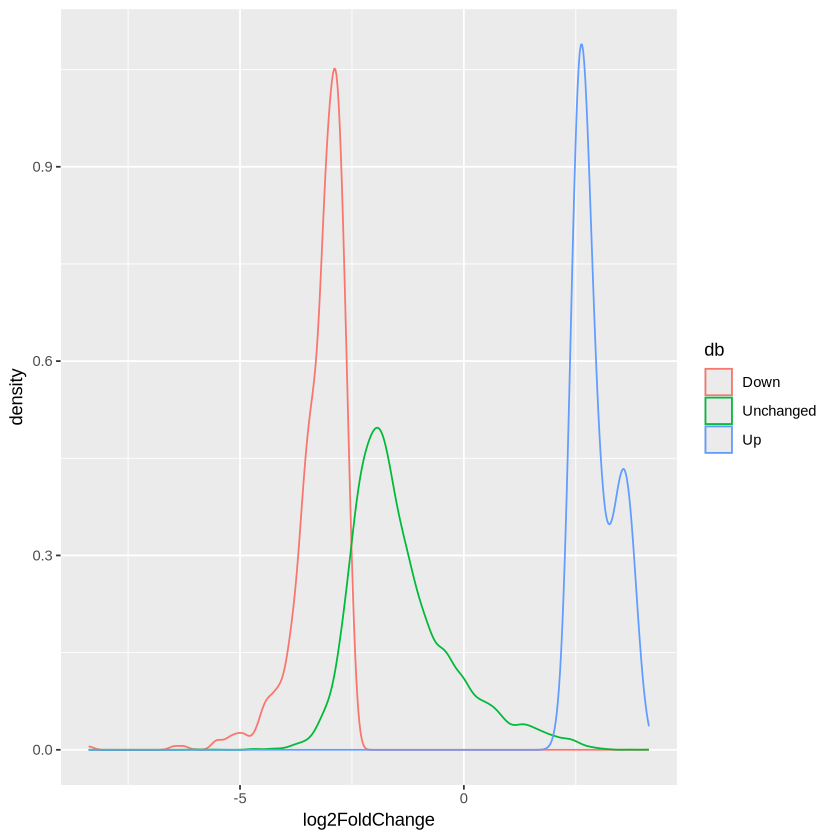

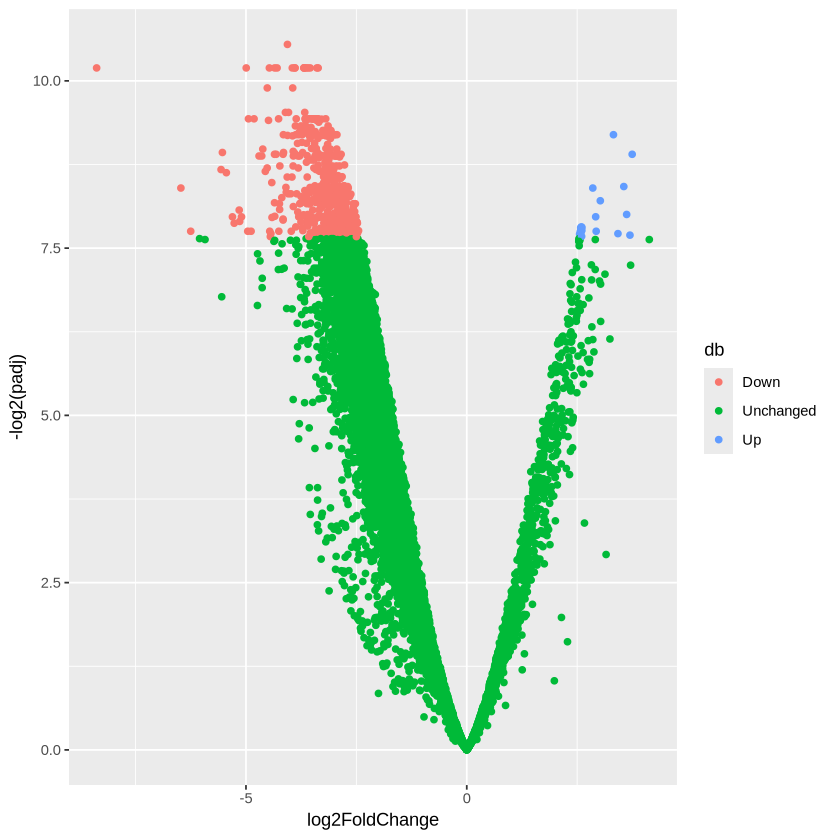

In [6]:
dthrexploration(mva)
mva <- dplot(mva)

In [7]:
rva$comp <- 'rva'
mva$comp <- 'mva'
outpath = "./postdeseq_37/"
write(unlist(rva |> filter(db == "Up") |> select(V1)), paste0(outpath,"rva_up.txt"))
write(unlist(rva |> filter(db == "Down") |> select(V1)), paste0(outpath,"rva_dn.txt"))
write(unlist(mva |> filter(db == "Up") |> select(V1)), paste0(outpath,"mva_up.txt"))
write(unlist(mva |> filter(db == "Down") |> select(V1)), paste0(outpath,"mva_dn.txt"))


allfiles <- rbind(rva,mva)
allfiles$comp<- factor(allfiles$comp,levels = c('mva','rva'))

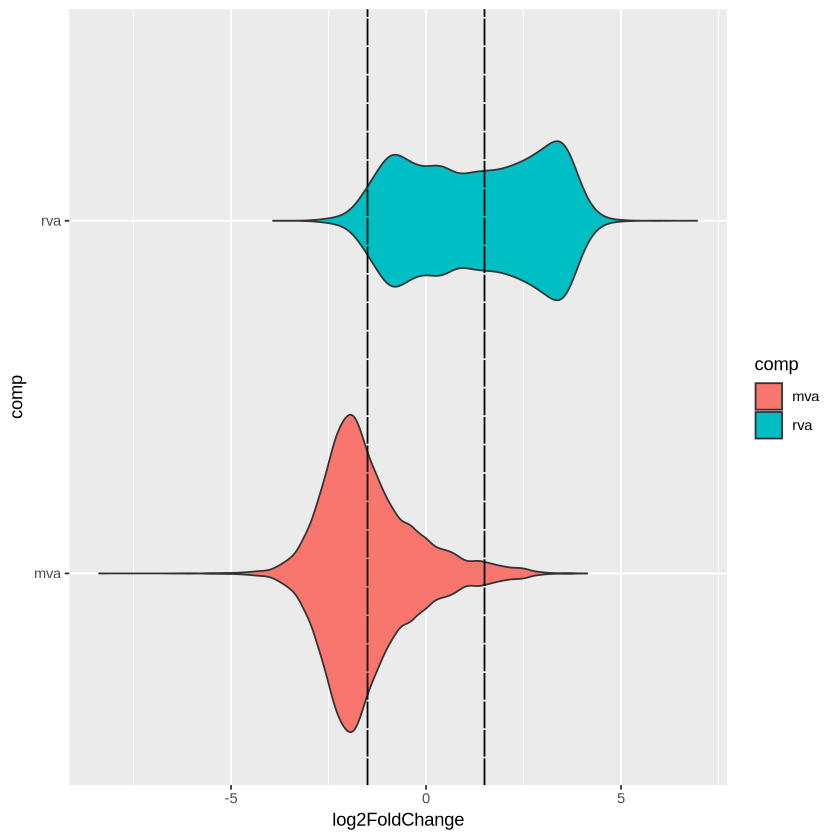

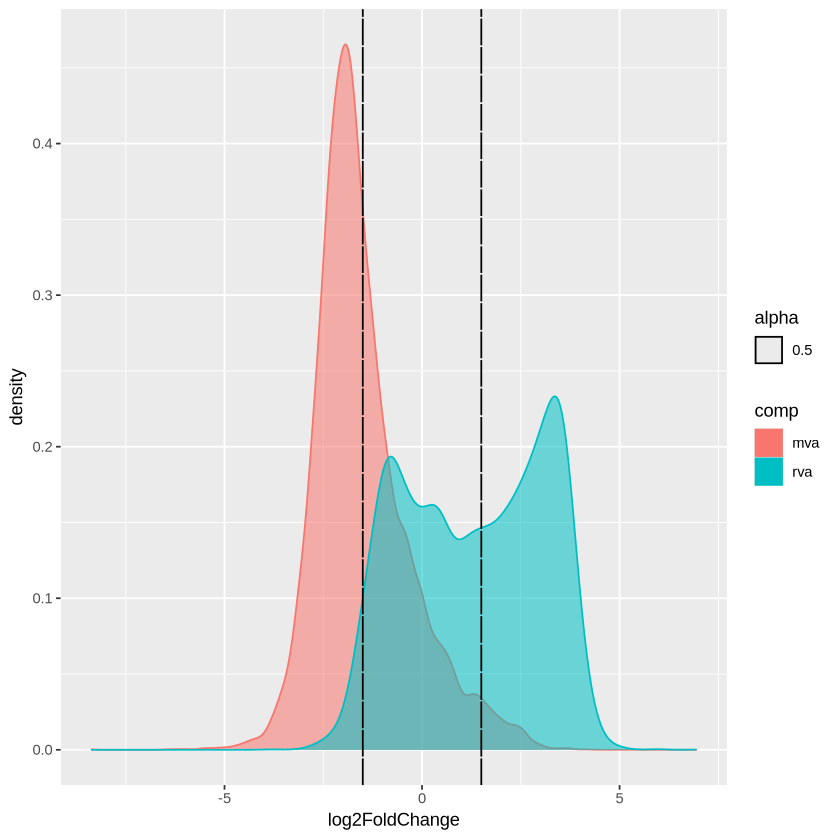

In [8]:
ggplot (allfiles, aes(x= log2FoldChange ,y = comp , fill
                      = comp)) + geom_violin() +
geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
geom_vline(xintercept= FCT, linetype="F1", color = "black") 

ggplot (allfiles, aes(x= log2FoldChange , fill = comp,color = comp, alpha = 0.5 )) + geom_density() +
geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
geom_vline(xintercept= FCT, linetype="F1", color = "black") 

In [9]:
bienPortadosBed <- read_tsv("deseq2_supportFiles_40/mockANDrescueNOTaux_GFP_DESEQNAMES.bed", col_names=F)

Rows: 1200 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): X1, X4
dbl (2): X2, X3

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [10]:
annoPeaks <- read_tsv("deseq2_supportFiles_40/picosReinberg_GFP.tsv", col_names=F)
glimpse(annoPeaks)
allfiles$reinberg <- "-"
for(i in 1:nrow(allfiles)){
    if (allfiles$V1[i] %in% annoPeaks$X4){
            allfiles$reinberg[i] <- unlist(filter(annoPeaks, X4 == allfiles$V1[i])$X13[1]) 
        }
    }

Rows: 47 Columns: 14
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): X1, X4, X5, X11, X13, X14
dbl (8): X2, X3, X6, X7, X8, X9, X10, X12

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 47
Columns: 14
$ X1  <chr> "chr2", "chr2", "chr2", "chr2", "chr2", "chr2", "chr6", "chr6", "c…
$ X2  <dbl> 74655991, 74657406, 38338943, 38354657, 38356380, 38351018, 845847…
$ X3  <dbl> 74656396, 74659583, 38340175, 38354906, 38357591, 38351998, 845859…
$ X4  <chr> "mockPeak_3207", "mockPeak_3208", "mockPeak_3155", "mockPeak_3158"…
$ X5  <chr> "Exon (ENSMUST00000001867.12/ENSMUSG00000001815.15, exon 3 of 3)",…
$ X6  <dbl> 2, 2, 2, 2, 2, 2, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, …
$ X7  <dbl> 74655616, 74652991, 38339281, 38353802, 38353802, 38351768, 845714…
$ X8  <dbl> 74659419, 74659557, 38369199, 38360089, 38360089, 38354631, 845876…
$ X9  <dbl> 3804, 6567, 29919, 6288, 6288, 2864, 16267, 16267, 16695, 3743, 87…
$ X10 <dbl> 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, …
$ X11 <chr> "ENSMUST00000173623.1", "ENSMUST00000001867.12", "ENSMUST000001437…
$ X12 <dbl> 3023, 0, 0, 856, 2579, 0, 1775, 0, -408, 0, 93, 475, 208, 484, 0, …
$ X13 <chr> "Evx2",

In [11]:
allfiles <- allfiles |> mutate(peakClass = str_remove(V1,"_.*")) |> mutate(bienPortados = case_when(V1 %in% bienPortadosBed$X4 ~ "Nucleation Dynamic", .default = "Not responsive"))
glimpse(allfiles)

Rows: 23,656
Columns: 14
$ baseMean       <dbl> 116.92880, 342.20273, 181.14285, 870.25306, 58.98086, 2…
$ log2FoldChange <dbl> 3.09474248, 3.18620674, 2.65192761, 4.00760758, 1.80308…
$ lfcSE          <dbl> 0.7339311, 0.6753840, 0.7840708, 0.7194326, 0.7949971, …
$ stat           <dbl> 4.21666628, 4.71762213, 3.38225510, 5.57051113, 2.26804…
$ pvalue         <dbl> 2.479405e-05, 2.386172e-06, 7.189335e-04, 2.539931e-08,…
$ padj           <dbl> 1.189230e-04, 1.755150e-05, 2.361062e-03, 9.272315e-07,…
$ V1             <chr> "mockPeak_1", "mockPeak_2", "mockPeak_3", "bulkPeak_4",…
$ Significative  <lgl> TRUE, TRUE, TRUE, TRUE, FALSE, FALSE, FALSE, FALSE, FAL…
$ directionality <chr> "UP", "UP", "UP", "UP", "UP", "DOWN", "UP", "UP", "UP",…
$ db             <fct> Up, Up, Up, Up, Unchanged, Unchanged, Unchanged, Unchan…
$ comp           <fct> rva, rva, rva, rva, rva, rva, rva, rva, rva, rva, rva, …
$ reinberg       <chr> "-", "-", "-", "-", "-", "-", "-", "-", "-", "-", "-", …
$ peakClass    

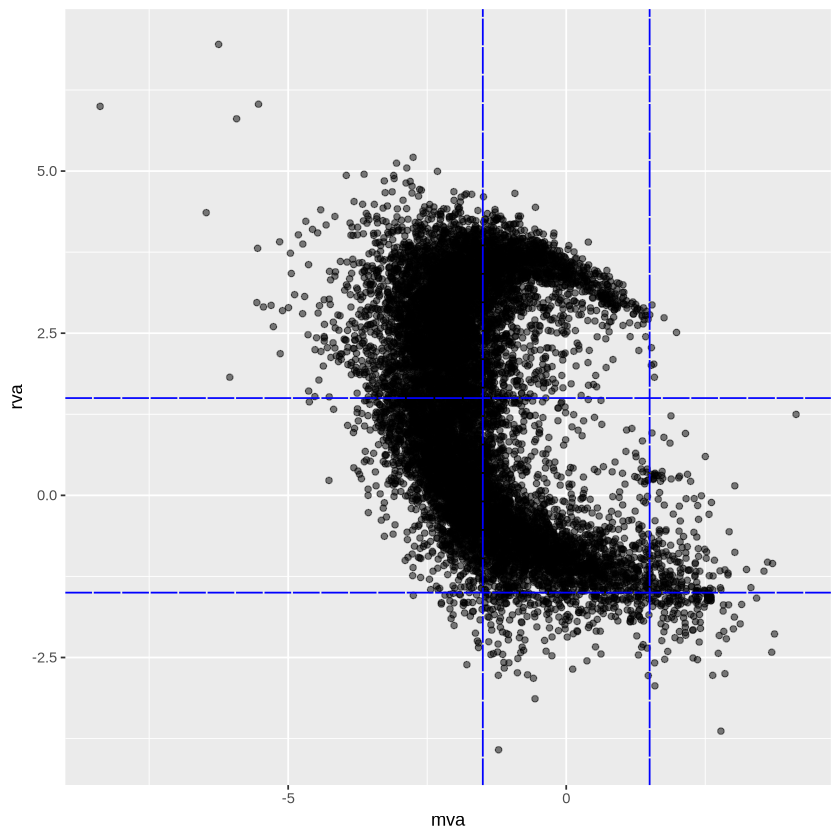

In [12]:
af <- allfiles |> select(V1,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
ggplot (af, aes (y= rva, x = mva)) + 
    geom_point(alpha = 0.5) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "blue") +
    geom_hline(yintercept= FCT, linetype="F1", color = "blue") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "blue") +
    geom_vline(xintercept= FCT, linetype="F1", color = "blue") 

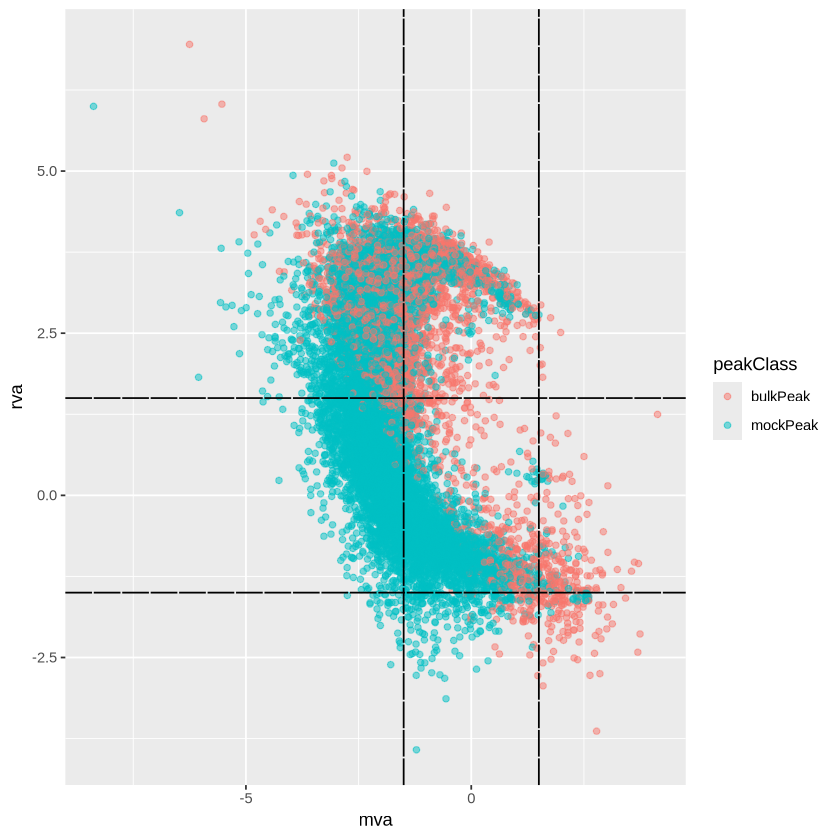

In [13]:
af <- allfiles |> select(V1,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
ggplot (af, aes (y= rva, x = mva, color = peakClass)) + 
    geom_point(alpha = 0.5) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") 

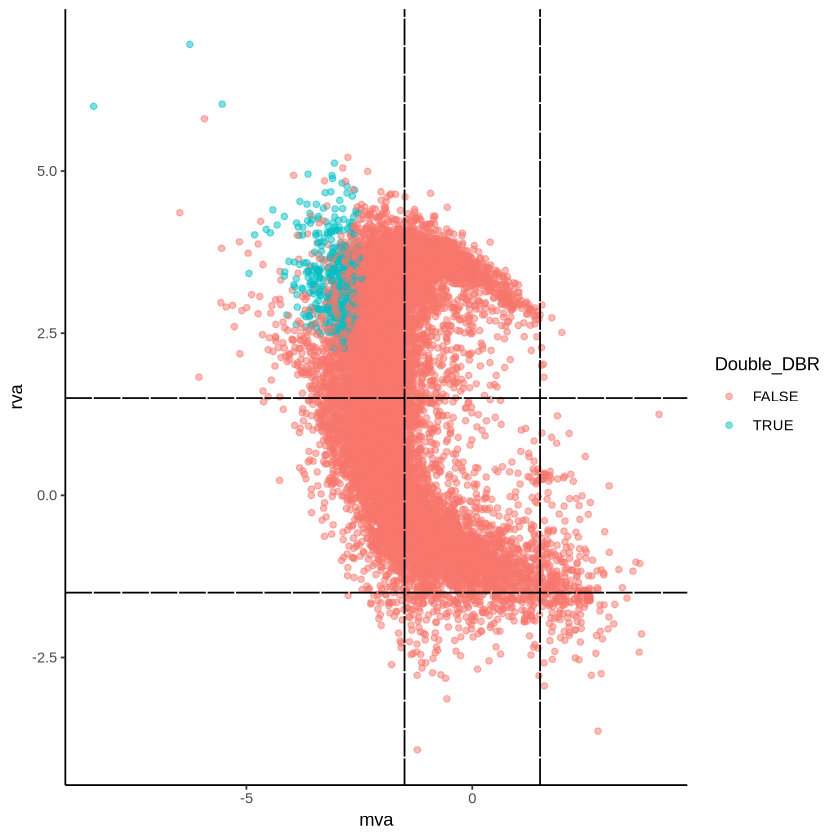

In [14]:
af <- allfiles |> select(V1,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
af$Double_DBR <- sigboth
plt <-ggplot (af, aes (y= rva, x = mva, color = Double_DBR)) + 
    geom_point(alpha = 0.5) +
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") +
    theme_classic()

plt

ggsave(filename = "/hdd/Itzel/NuevoTodo//plotsJul2025/cuadrantesK27.pdf", plot = plt, height = 8, width = 8)

Rows: 11888 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): X1, X4
dbl (2): X2, X3

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


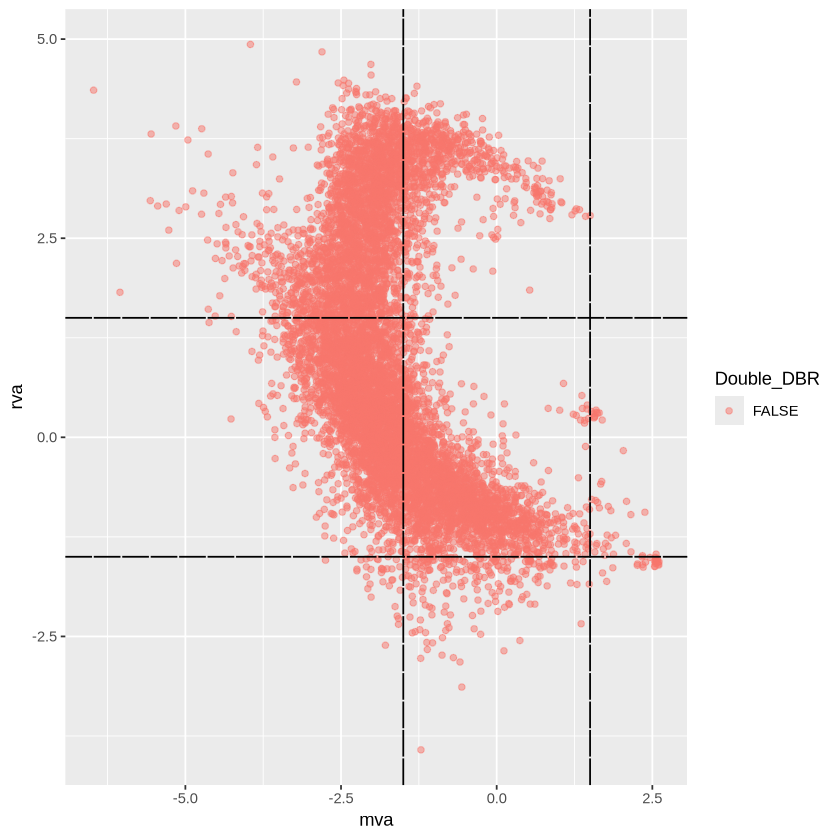

In [15]:
af <- allfiles |> select(V1,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
af$Double_DBR <- sigboth
bpdeseq <- unlist(af |> filter(Double_DBR == TRUE) |> select(V1))
af <- af |> filter(peakClass == "mockPeak") |> filter(Double_DBR == FALSE)
ggplot (af, aes (y= rva, x = mva, color = Double_DBR)) + 
    geom_point(alpha = 0.5) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") 

restoPicosMockNames <- as.vector(unlist(af$V1))

bpdeseq <-as.vector(bpdeseq)
peakBed <- read_tsv("/hdd/Itzel/NuevoTodo/macs2peaksUnionSet_MockAuxResc_19/allPeaks_K27.bed", col_names = F)
bpdeseqbed <- peakBed |> filter(X4 %in% bpdeseq)
write_tsv(bpdeseqbed, "/hdd/Itzel/NuevoTodo/bienPortadosDeseq_bed_41/bienPortadosDeseq_K27.bed", col_names = F)
restomockbed <- peakBed |> filter(X4 %in% restoPicosMockNames)
write_tsv(restomockbed, "/hdd/Itzel/NuevoTodo/bienPortadosDeseq_bed_41/restoPicosMockDeseq_K27.bed", col_names = F)


Rows: 11,828
Columns: 5
$ V1         <chr> "mockPeak_1", "mockPeak_2", "mockPeak_3", "bulkPeak_4", "mo…
$ peakClass  <chr> "mockPeak", "mockPeak", "mockPeak", "bulkPeak", "mockPeak",…
$ rva        <dbl> 3.09474248, 3.18620674, 2.65192761, 4.00760758, 1.80308587,…
$ mva        <dbl> -2.3142377, -1.7913261, -2.9099971, -1.8068591, -2.1127215,…
$ Double_DBR <lgl> FALSE, FALSE, TRUE, FALSE, FALSE, FALSE, FALSE, FALSE, FALS…
Rows: 3,131
Columns: 5
$ V1         <chr> "bulkPeak_4", "bulkPeak_10", "bulkPeak_11", "bulkPeak_12", …
$ peakClass  <chr> "bulkPeak", "bulkPeak", "bulkPeak", "bulkPeak", "bulkPeak",…
$ rva        <dbl> 4.0076076, 2.7120341, 2.5735504, 3.6286557, 4.4407804, 3.20…
$ mva        <dbl> -1.8068591, -1.2618617, -2.9340913, -1.6112232, -0.5533122,…
$ Double_DBR <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FAL…


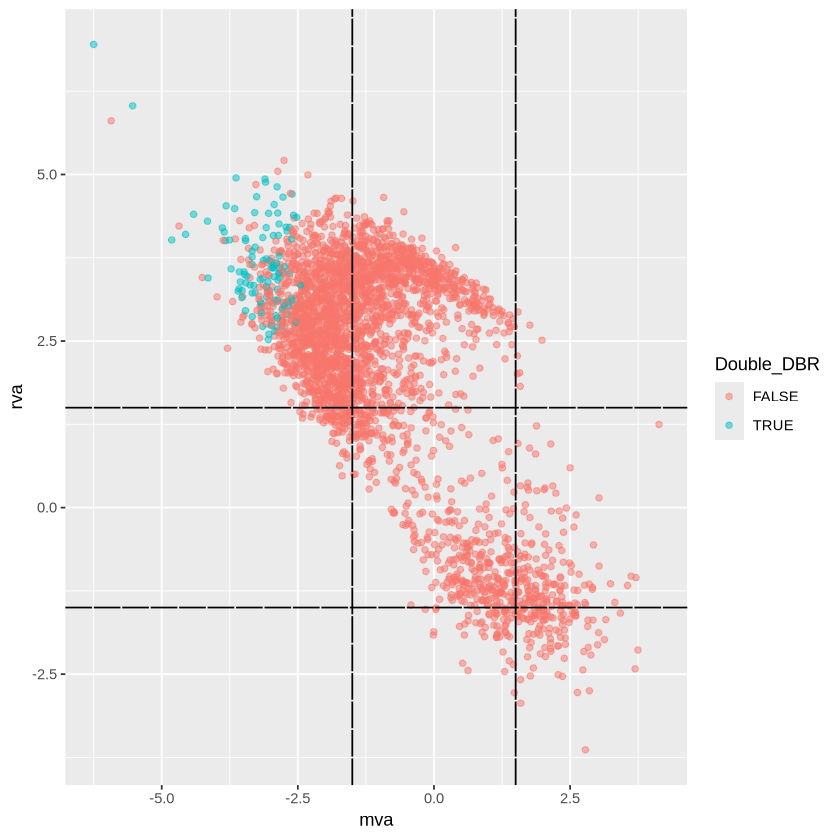

In [16]:
af <- allfiles |> select(V1,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
af$Double_DBR <- sigboth
glimpse(af)
af <- af |> filter(peakClass != "mockPeak")
glimpse(af)
ggplot (af, aes (y= rva, x = mva, color = Double_DBR)) + 
    geom_point(alpha = 0.5) +
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") 

In [17]:
annoPeaks <- read_tsv("deseq2_supportFiles_40/picosReinberg_K27.tsv", col_names=F)
glimpse(annoPeaks)
allfiles$reinberg <- "-"
for(i in 1:nrow(allfiles)){
    if (allfiles$V1[i] %in% annoPeaks$X4){
            allfiles$reinberg[i] <- unlist(filter(annoPeaks, X4 == allfiles$V1[i])$X13[1]) 
        }
    }

Rows: 39 Columns: 14
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): X1, X4, X5, X11, X13, X14
dbl (8): X2, X3, X6, X7, X8, X9, X10, X12

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 39
Columns: 14
$ X1  <chr> "chr2", "chr2", "chr2", "chr2", "chr2", "chr2", "chr6", "chr6", "c…
$ X2  <dbl> 74656180, 74648440, 38354308, 38337818, 38348663, 38351847, 845892…
$ X3  <dbl> 74661320, 74649915, 38355368, 38341227, 38350610, 38353667, 845902…
$ X4  <chr> "bulkPeak_5912", "bulkPeak_5911", "bulkPeak_5610", "bulkPeak_5609"…
$ X5  <chr> "Promoter (<=1kb)", "Distal Intergenic", "Promoter (<=1kb)", "Prom…
$ X6  <dbl> 2, 2, 2, 2, 2, 2, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 11, 11, 11, …
$ X7  <dbl> 74652991, 74655616, 38353802, 38339281, 38350759, 38352532, 845719…
$ X8  <dbl> 74659557, 74659419, 38360089, 38369199, 38369733, 38354573, 845886…
$ X9  <dbl> 6567, 3804, 6288, 29919, 18975, 2042, 16695, 16267, 3743, 2083, 24…
$ X10 <dbl> 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, …
$ X11 <chr> "ENSMUST00000001867.12", "ENSMUST00000173623.1", "ENSMUST000001758…
$ X12 <dbl> 0, 9504, 507, 0, -149, 0, -648, 0, 0, 505, 0, 613, 0, 0, 0, 272, 0…
$ X13 <chr> "Evx2",

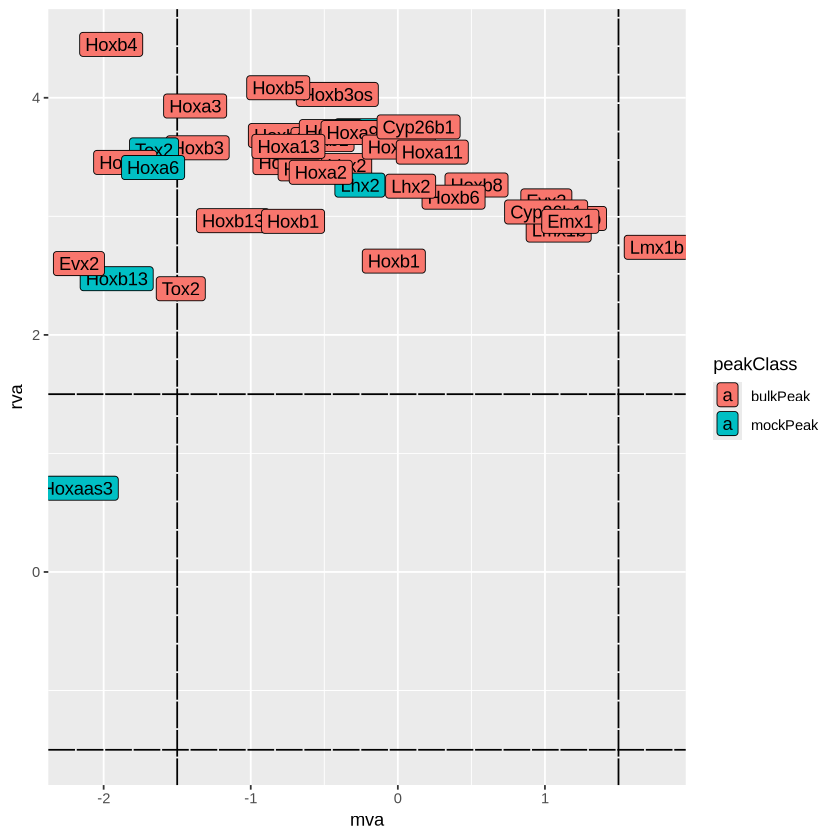

In [18]:
af <- allfiles |> select(V1,reinberg,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange) 
af$Double_DBR <- sigboth
af <- filter(af ,reinberg != "-")
ggplot (af, aes (y= rva, x = mva, fill = peakClass, label = reinberg)) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") +
    #geom_text(size =3, aes(color = factor(reinberg)))+
    geom_label()

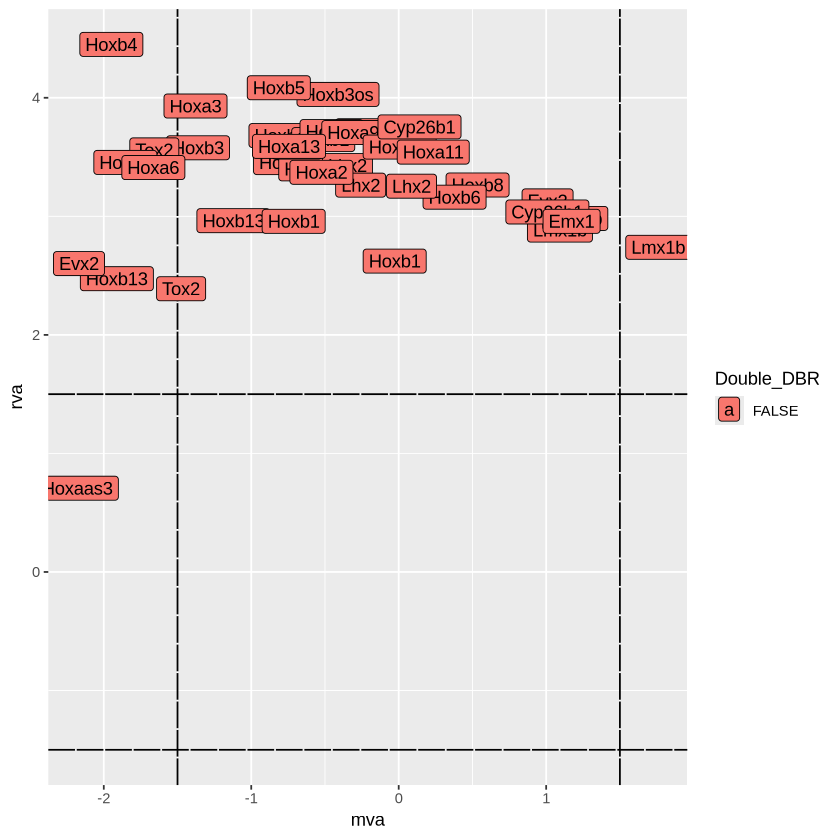

In [19]:
af <- allfiles |> select(V1,reinberg,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange) 
af$Double_DBR <- sigboth
af <- filter(af ,reinberg != "-")
ggplot (af, aes (y= rva, x = mva, fill = Double_DBR, label = reinberg)) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") +
    #geom_text(size =3, aes(color = factor(reinberg)))+
    geom_label()

In [20]:
af <- allfiles |> select(V1,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
af$Double_DBR <- sigboth
bpdeseq <- as.vector(unlist(af |> filter(Double_DBR == TRUE) |> select(V1)))
peakBed <- read_tsv("/hdd/Itzel/NuevoTodo/macs2peaksUnionSet_MockAuxResc_19/allPeaks_K27.bed", col_names = F)
bpdeseqbed <- peakBed |> filter (X4 %in% bpdeseq)
write_tsv(bpdeseqbed, "/hdd/Itzel/NuevoTodo/bienPortadosDeseq_bed_41/bienPortadosDeseq_K27.bed", col_names = F)

Rows: 11888 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): X1, X4
dbl (2): X2, X3

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
